In [1]:
import uproot
import numpy as np
import pandas as pd
import awkward as ak
import matplotlib.pyplot as plt
import pickle
import os
from scipy.constants import c
import sys

sys.path.append("..")

DATA_DIR = "../mu3e_trigger_data"
ROOT_DATA_DIR = "../mu3e_root_data"
signal_data_file = f"{ROOT_DATA_DIR}/run_sig_simi-sort.root"
background_data_file = f"{ROOT_DATA_DIR}/run_bg_simi-sort.root"
e5_data_file = f"{ROOT_DATA_DIR}/run42_5e-sort.root"
familong_data_file = f"{ROOT_DATA_DIR}/run_familon_simi-sort.root"
signal_only_data_file = f"{ROOT_DATA_DIR}/run42_sig_only-sort.root"

HIT_COUNT_CUTOFF = 256

In [14]:

sig_number_mppc_hits = []
sig_number_pixels_hits = []
bg_number_mppc_hits = []
bg_number_pixel_hits = []
with uproot.open(background_data_file) as file:
    mppc_tree = file["mu3e/fibremppc_mppc"].arrays(library="pd")["fibremppc_mppc"]
    pixel_tree = file["mu3e/hit_pixelid"].arrays(library="pd")["hit_pixelid"]
for event in mppc_tree:
    bg_number_mppc_hits.append(len(event.to_list()))
for event in pixel_tree:
    hit_ids = np.array(event.to_list())
    bg_number_pixel_hits.append((((hit_ids // 2**16 ) // 2**12) == 0).sum())

with uproot.open(signal_data_file) as file:
    mppc_tree = file["mu3e/fibremppc_mppc"].arrays(library="pd")["fibremppc_mppc"]
    pixel_tree = file["mu3e/hit_pixelid"].arrays(library="pd")["hit_pixelid"]
for event in mppc_tree:
    sig_number_mppc_hits.append(len(event.to_list()))
for event in pixel_tree:
    hit_ids = np.array(event.to_list())
    sig_number_pixels_hits.append((((hit_ids // 2**16) // 2**12) == 0).sum())

sig_number_mppc_hits = np.array(sig_number_mppc_hits)
sig_number_pixels_hits = np.array(sig_number_pixels_hits)
bg_number_mppc_hits = np.array(bg_number_mppc_hits)
bg_number_pixel_hits = np.array(bg_number_pixel_hits)


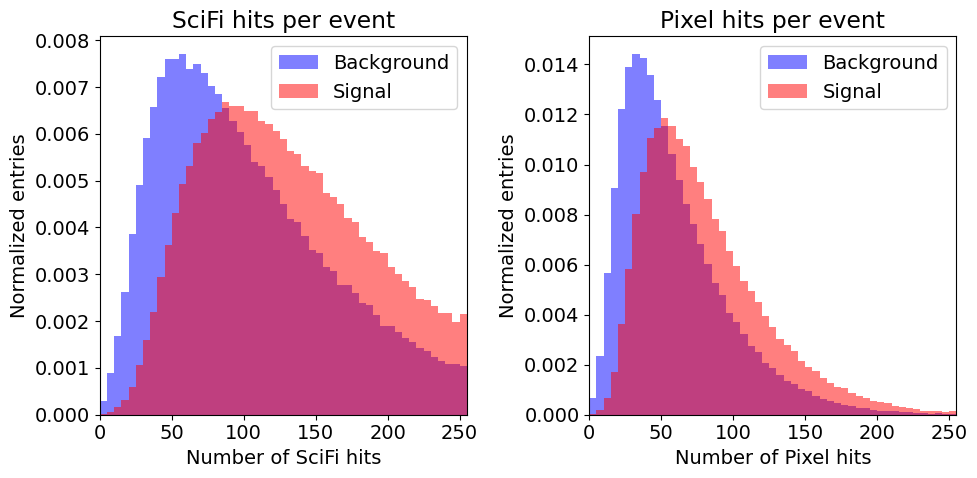

In [20]:
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(
    bg_number_mppc_hits,
    bins=np.arange(0, HIT_COUNT_CUTOFF, 5),
    label="Background",
    density=True,
    color="blue",
    alpha=0.5,
)
ax[0].hist(
    sig_number_mppc_hits,
    bins=np.arange(0, HIT_COUNT_CUTOFF, 5),
    label="Signal",
    density=True,
    color="red",
    alpha=0.5,
)
ax[0].set_xlabel("Number of SciFi hits")
ax[0].set_ylabel("Normalized entries")
ax[0].legend()
ax[0].set_title("SciFi hits per event")
ax[0].set_xlim(0, (HIT_COUNT_CUTOFF//5)*5)

ax[1].hist(
    bg_number_pixel_hits,
    bins=np.arange(0, HIT_COUNT_CUTOFF, 5),
    label="Background",
    density=True,
    color="blue",
    alpha=0.5,

)
ax[1].hist(
    sig_number_pixels_hits,
    bins=np.arange(0, HIT_COUNT_CUTOFF, 5),
    label="Signal",
    density=True,
    color="red",
    alpha=0.5,
)
ax[1].set_xlabel("Number of Pixel hits")
ax[1].set_ylabel("Normalized entries")
ax[1].legend()
ax[1].set_title("Pixel hits per event")
ax[1].set_xlim(0, (HIT_COUNT_CUTOFF//5)*5)
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/hit_multiplicity.png")
plt.show()


In [2]:
from src.data_preparation import convert_root_to_npy, get_image_slices_from_root

In [3]:
if True:
    convert_root_to_npy(
        file_path=signal_data_file,
        out_dir=DATA_DIR,
        out_name="sig",
        padding_value=-1,
        hit_cutoff=HIT_COUNT_CUTOFF,
        add_layer_as_feature=True,
    )
    convert_root_to_npy(
        file_path=background_data_file,
        out_dir=DATA_DIR,
        out_name="bg",
        padding_value=-1,
        hit_cutoff=HIT_COUNT_CUTOFF,
        add_layer_as_feature=True,
    )
    convert_root_to_npy(
        file_path=e5_data_file,
        out_dir=DATA_DIR,
        out_name="5e",
        padding_value=-1,
        hit_cutoff=HIT_COUNT_CUTOFF,
        add_layer_as_feature=True,
    )
    convert_root_to_npy(
        file_path=familong_data_file,
        out_dir=DATA_DIR,
        out_name="familon",
        padding_value=-1,
        hit_cutoff=HIT_COUNT_CUTOFF,
        add_layer_as_feature=True,
    )
    convert_root_to_npy(
        file_path=signal_only_data_file,
        out_dir=DATA_DIR,
        out_name="sig_only",
        padding_value=-1,
        hit_cutoff=HIT_COUNT_CUTOFF,
        add_layer_as_feature=True,
    )

Saved pixel spacetime to ../mu3e_trigger_data/sig_with_layer_pixel_spacetime.npy with shape (177028, 256, 6)
Saved MPPC spacetime to ../mu3e_trigger_data/sig_with_layer_mppc_spacetime.npy with shape (177028, 256, 6)
Saved pixel spacetime to ../mu3e_trigger_data/bg_with_layer_pixel_spacetime.npy with shape (189252, 256, 6)
Saved MPPC spacetime to ../mu3e_trigger_data/bg_with_layer_mppc_spacetime.npy with shape (189252, 256, 6)
Saved pixel spacetime to ../mu3e_trigger_data/5e_with_layer_pixel_spacetime.npy with shape (90790, 256, 6)
Saved MPPC spacetime to ../mu3e_trigger_data/5e_with_layer_mppc_spacetime.npy with shape (90790, 256, 6)
Saved pixel spacetime to ../mu3e_trigger_data/familon_with_layer_pixel_spacetime.npy with shape (76165, 256, 6)
Saved MPPC spacetime to ../mu3e_trigger_data/familon_with_layer_mppc_spacetime.npy with shape (76165, 256, 6)
Saved pixel spacetime to ../mu3e_trigger_data/sig_only_with_layer_pixel_spacetime.npy with shape (91519, 256, 6)
Saved MPPC spacetime to

In [4]:
if False:
    get_image_slices_from_root(
        file_path=signal_data_file,
        out_dir=DATA_DIR,
        out_name="sig",
        padding_value=-1,
        hit_cutoff=HIT_COUNT_CUTOFF,
    )
    get_image_slices_from_root(
        file_path=background_data_file,
        out_dir=DATA_DIR,
        out_name="bg",
        padding_value=-1,
        hit_cutoff=HIT_COUNT_CUTOFF,
    )
    get_image_slices_from_root(
        file_path=e5_data_file,
        out_dir=DATA_DIR,
        out_name="e5",
        padding_value=-1,
        hit_cutoff=HIT_COUNT_CUTOFF,
    )
    get_image_slices_from_root(
        file_path=familong_data_file,
        out_dir=DATA_DIR,
        out_name="familon",
        padding_value=-1,
        hit_cutoff=HIT_COUNT_CUTOFF,
    )
    get_image_slices_from_root(
        file_path=signal_only_data_file,
        out_dir=DATA_DIR,
        out_name="sig_only",
        padding_value=-1,
        hit_cutoff=HIT_COUNT_CUTOFF,
    )

In [5]:
def convert_pixel_id_to_nla(
    pixel_id: np.ndarray, padding_value: int = -1
) -> np.ndarray:
    nla = np.full((*pixel_id.shape, 4), padding_value, dtype=np.int32)
    valid_mask = pixel_id != padding_value

    chip_id = pixel_id // 2**16
    station = chip_id // 2**12
    layer = ((chip_id // 2**10) % 4) + 1
    phi = ((chip_id // 2**5) % 2**5) + 1
    z_prime = chip_id % 2**5

    z = np.where(layer == 3, z_prime - 7, np.where(layer == 4, z_prime - 6, z_prime))

    station_mask = station == 0
    valid_mask = valid_mask & station_mask

    nla[valid_mask, 0] = station[valid_mask]
    nla[valid_mask, 1] = layer[valid_mask]
    nla[valid_mask, 2] = phi[valid_mask]
    nla[valid_mask, 3] = z[valid_mask]

    return nla

In [6]:
def convert_pixel_timestamp_to_ns(pixel_timestamp):
    time_ns = pixel_timestamp * 8
    return time_ns
def adjust_pixel_timestamps(
    timestamps: np.ndarray, padding_value: int = -1, timeframe_length=64
) -> np.ndarray:
    """
    Adjusts timestamps based on the data mask.
    If data is padded, the corresponding timestamps are set to -1.
    """
    shape = timestamps.shape
    flat_timestamps = timestamps.flatten()
    flat_mask = flat_timestamps != padding_value
    flat_timestamps[flat_mask] = convert_pixel_timestamp_to_ns(
        flat_timestamps[flat_mask]
    )
    flat_timestamps[flat_mask] = (
        flat_timestamps[flat_mask]
        - (flat_timestamps[flat_mask] // timeframe_length) * timeframe_length
    )
    adjusted_timestamps = flat_timestamps.reshape(shape)
    return adjusted_timestamps

